# Students Performance：試験成績の差に結びつく要因

run_id: `v020-exp-10`。出典：指定のKaggle公開データをAPIで検索・認証・取得し、バイト列SHA-256を保存する。認証情報は表示・保存しない。

## 分析計画（実行前）
対象は取得した全行。主指標は数学・読解・作文の等重み平均、補助指標は科目別得点。カテゴリの件数・平均・標準偏差、主要3比較（準備講座、昼食区分、gender）のWelch平均差・95%区間・標準化差を示し、3比較内のHolm補正を行う。全5要因をカテゴリとして同時投入したOLSとHC3標準誤差で観測要因を調整する。学歴を勝手に線形順序化しない。因果効果・予測ランキング・全国代表値ではない。

結果読後に科目別、相互作用・層別、モデル仕様の安定性など、結論に実質的な影響がある点を最大3回追加検討する。乱数seedを固定し、最後に新しいカーネルで全コードセルを順番に実行する。

## 限界と解釈方針
準備講座は自己選択、昼食は経済状態の不完全な代理指標になり得るが制度の詳細は未確認。事前学力、学校・教師、所得、学習時間、受講時期、欠席等がないため、交絡を取り除いたとは言えない。gender/ethnicityはデータのラベルであり生物学的・本質的説明にしない。標本設計・国・年度・生徒ID・学校クラスタ不明。HC3は異分散対応であってクラスタ依存対応ではない。信頼区間は標本が独立という作業仮定に依存する。

## 適用できない機能
独立の参照データが提供されていないため `data_quality.validate_anomalies` と `dataset_validation.compare_datasets` は適用しない。同一CSVミラーは独立検証にならない。欠損補完は欠損がある場合のみ検討する。自動機械学習・因果同定は目的外。`mcp_gateway.run_and_record` はこの対話ツールにPython MCPClientオブジェクトがないため未使用：実セルはJupyter MCPのexecute_cellで実行し、作成・追記・メタデータ書込みはenqueue_writeで直列化する。偽のexecuteアダプターで直接Python実行をMCPと称することはしない。


In [1]:
from pathlib import Path
import os, sys, json, io, hashlib, zipfile, contextlib, warnings
from datetime import datetime, timezone
from dataclasses import asdict
from importlib.metadata import version
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'ai_data_scientist').exists())
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark' / 'projects')
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from IPython.display import display
from ai_data_scientist import project_manager, language_router, lifecycle, ingestion, cleaning, eda, stats_analysis, visualization, data_definition, analysis_assumptions, data_quality, sensitivity, insight_engine, notebook_audit
RUN_ID = 'v020-exp-10'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-10-students')
lifecycle.register_run(RUN_ID, handle.notebook_path)
DATA_DIR = project_manager.ensure_data_dir(handle)
SEED = 20261002
phase_log = []
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda v: f'{v:.6g}')
@contextlib.contextmanager
def phase(name, write=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Cancellation requested')
    start = lifecycle.mark_write_start if write else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if write else lifecycle.mark_execution_end
    start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase': name, 'event': 'failed', 'exception_type': type(exc).__name__})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase': name, 'event': 'end', 'utc': datetime.now(timezone.utc).isoformat()})
print({'run_id': RUN_ID, 'language': language_router.detect_language('試験成績の差の要因分析'), 'seed': SEED, 'python': sys.version.split()[0], 'pandas': pd.__version__, 'numpy': np.__version__})

print('実行依存環境:', {p:version(p) for p in ['scipy','statsmodels','matplotlib','kaggle','nbformat','japanize-matplotlib']})


{'run_id': 'v020-exp-10', 'language': 'ja', 'seed': 20261002, 'python': '3.12.3', 'pandas': '3.0.6', 'numpy': '2.5.3'}
実行依存環境: {'scipy': '1.18.1', 'statsmodels': '0.15.0', 'matplotlib': '3.11.2', 'kaggle': '2.2.4', 'nbformat': '5.11.1', 'japanize-matplotlib': '1.1.3'}


In [2]:
with phase('Kaggle検索・取得'):
    SLUG = 'spscientist/students-performance-in-exams'
    FILENAME = 'StudentsPerformance.csv'
    csv_path = DATA_DIR / FILENAME
    provenance_path = DATA_DIR / 'provenance.json'
    api_failure = None
    step = 'SDK import'
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            step = 'authenticate'
            api.authenticate()
            step = 'dataset_list'
            matches = api.dataset_list(search='students performance in exams')
            refs = [str(d.ref) for d in matches]
            if SLUG not in refs:
                matches = api.dataset_list(search='spscientist students performance')
                refs += [str(d.ref) for d in matches]
            if SLUG not in refs:
                raise LookupError('Requested slug was not found')
            step = 'dataset_list_files'
            listing = api.dataset_list_files(SLUG)
            files = [str(f.name) for f in listing.files]
            if FILENAME not in files:
                raise FileNotFoundError('Requested CSV was not listed')
            step = 'dataset_download_file'
            cached = json.loads(provenance_path.read_text()) if provenance_path.exists() else None
            cache_ok = csv_path.exists() and cached and cached.get('source') == 'Kaggle API' and hashlib.sha256(csv_path.read_bytes()).hexdigest() == cached.get('sha256')
            if not cache_ok:
                api.dataset_download_file(SLUG, FILENAME, path=str(DATA_DIR), force=True, quiet=True)
                if not csv_path.exists():
                    archive = DATA_DIR / (FILENAME + '.zip')
                    with zipfile.ZipFile(archive) as z:
                        if FILENAME not in z.namelist():
                            raise FileNotFoundError('Expected archive member missing')
                        csv_path.write_bytes(z.read(FILENAME))
                provenance = {'source': 'Kaggle API', 'owner_dataset_slug': SLUG, 'filename': FILENAME, 'source_url': 'https://www.kaggle.com/datasets/' + SLUG, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'listed_files': files}
            else:
                provenance = cached
        print({'Kaggle検索結果': [r for r in refs if r == SLUG], '公開ファイル': files, '認証情報': '非表示'})
    except Exception as exc:
        # Exception messages/SDK captured output can contain credentials: never persist them.
        api_failure = {'step': step, 'exception_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'details': '認証情報保護のため例外本文とSDK出力は記録しない。'}
        print({'Kaggle API失敗': api_failure})
        paper = Path('/home/nahisaho/kaggle/experiments/white-paper.md').read_text(encoding='utf-8')
        FALLBACK_URL = 'https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv'
        assert FALLBACK_URL in paper, '旧実験のCSV URLを確認できない'
        import urllib.request
        with urllib.request.urlopen(FALLBACK_URL, timeout=60) as response:
            raw = response.read(2_000_001)
        assert len(raw) <= 2_000_000, 'Download size limit exceeded'
        csv_path.write_bytes(raw)
        provenance = {'source': '旧実験の公開CSV（フォールバック）', 'owner_dataset_slug': SLUG, 'filename': FILENAME, 'source_url': FALLBACK_URL, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(raw).hexdigest(), 'kaggle_failure': api_failure, 'fallback_reason': 'Kaggle APIで対応する公開データを検索・取得できなかったため', 'identity_caveat': '公開CSVとKaggle掲載版の完全な同一性は保証されない'}
    with phase('来歴ファイル保存', write=True):
        provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    ingest_result = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=10000)
    assert not ingest_result.truncated, '全件分析の行数制限を超えた'
    raw_df = ingest_result.dataframe
    display(provenance)
    display(raw_df.head())


{'Kaggle検索結果': ['spscientist/students-performance-in-exams'], '公開ファイル': ['StudentsPerformance.csv'], '認証情報': '非表示'}


{'source': 'Kaggle API',
 'owner_dataset_slug': 'spscientist/students-performance-in-exams',
 'filename': 'StudentsPerformance.csv',
 'source_url': 'https://www.kaggle.com/datasets/spscientist/students-performance-in-exams',
 'retrieved_at_utc': '2026-10-01T18:40:25.330816+00:00',
 'sha256': 'ade5869dba8b2d3e2b96379359fb2f61cb0308e8394d9b1ba37e174cfe3bee69',
 'listed_files': ['StudentsPerformance.csv']}

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
with phase('データ定義・意味検査'):
    score_cols = ['math score', 'reading score', 'writing score']
    categories = {'gender': ['female', 'male'], 'race/ethnicity': ['group A','group B','group C','group D','group E'], 'parental level of education': ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school'], 'lunch': ['standard', 'free/reduced'], 'test preparation course': ['none', 'completed']}
    assert set(raw_df.columns) == set(score_cols + list(categories)), 'Unexpected or missing columns'
    schema = {c: {'min': 0, 'max': 100, 'not_null': True} for c in score_cols}
    schema.update({c: {'allowed': vals, 'not_null': True} for c, vals in categories.items()})
    semantic_findings = data_quality.detect_anomalies(raw_df, schema)
    numeric_failures = {c: int(pd.to_numeric(raw_df[c], errors='coerce').isna().sum()) for c in score_cols}
    assert not semantic_findings and not any(numeric_failures.values()), '意味的な異常を解決してから分析する必要がある'
    clean_result = cleaning.clean_dataset(raw_df, operation='drop_na')
    print('欠損除去影響:', {'rows_before': len(raw_df), 'rows_after': len(clean_result.dataframe), 'columns_before': len(raw_df.columns), 'columns_after': len(clean_result.dataframe.columns)})
    df = raw_df.rename(columns={'gender':'gender','race/ethnicity':'ethnicity','parental level of education':'parent_education','lunch':'lunch','test preparation course':'preparation','math score':'math','reading score':'reading','writing score':'writing'}).copy()
    df['average'] = df[['math','reading','writing']].mean(axis=1)
    FV = data_definition.FieldValue
    definitions = data_definition.build_manifest(source={k: FV(v, 'verified', '取得バイト列・API応答') for k,v in provenance.items() if k in ['owner_dataset_slug','filename','retrieved_at_utc','sha256','source_url']}, dataset_scope={'row_unit': FV('生徒と推測される1行', 'inferred','列名'), 'population': FV(None,'unknown'), 'sampling_method': FV(None,'unknown'), 'country_year_school': FV(None,'unknown'), 'independent_students': FV(None,'unknown')}, variables={c:{'definition':FV('試験の'+c if c in score_cols else 'CSVのカテゴリラベル（操作的定義は未確認）','inferred','CSV列名'), 'unit':FV('0–100の数値尺度。100点満点の制度は未検証' if c in score_cols else 'カテゴリ','inferred','観測範囲'), 'measurement_protocol':FV(None,'unknown')} for c in raw_df.columns}, transformations=('欠損なしを検証、主分析では重複行を保持（生徒IDなし）','列名短縮','3科目の等重み平均（探索用の合成指標）'))
    print('意味的異常:', [asdict(x) for x in semantic_findings], '数値変換失敗:', numeric_failures)
    print('欠損セル:', int(raw_df.isna().sum().sum()), '完全一致重複行:', int(raw_df.duplicated().sum()), '0点:', {c:int((raw_df[c]==0).sum()) for c in score_cols})
    print('不明な定義:', [(p, asdict(v)) for p,v in definitions.unresolved_fields()])
    print('推測された定義:', {c:asdict(v['definition']) for c,v in definitions.variables.items()})
    display(eda.explore(raw_df))
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(analysis_scope={'outcome':'3科目別および等重み平均','comparison':'Welch平均差とHC3調整回帰','target':'取得標本内の関連'}, causal_scope='associational', sampling={'n':len(df),'seed':SEED}, assumptions=(analysis_assumptions.Assumption('A1','行は独立した生徒であり、学校内クラスタ依存は無視できる','assumed',conclusion_critical=True,impact_if_false='信頼区間が狭すぎる可能性'),analysis_assumptions.Assumption('A2','等重み平均は科目横断の記述要約として使える','assumed',conclusion_critical=True,impact_if_false='科目別の差を隠す可能性。科目別感度分析を実施'),analysis_assumptions.Assumption('A3','無作為抽出と未測定交絡なしは検証されていない','rejected',conclusion_critical=True,impact_if_false='母集団への一般化と因果推論は行わない'),analysis_assumptions.Assumption('A4','欠損・範囲・カテゴリ・数値型検査を通過','verified',conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumptions)
    print('分析前提manifest:', asdict(assumptions))
    print('前提検査の全指摘:', [asdict(f) for f in assumption_findings])


欠損除去影響: {'rows_before': 1000, 'rows_after': 1000, 'columns_before': 8, 'columns_after': 8}
意味的異常: [] 数値変換失敗: {'math score': 0, 'reading score': 0, 'writing score': 0}
欠損セル: 0 完全一致重複行: 0 0点: {'math score': 1, 'reading score': 0, 'writing score': 0}
不明な定義: [('dataset_scope.population', {'value': None, 'status': 'unknown', 'source': None}), ('dataset_scope.sampling_method', {'value': None, 'status': 'unknown', 'source': None}), ('dataset_scope.country_year_school', {'value': None, 'status': 'unknown', 'source': None}), ('dataset_scope.independent_students', {'value': None, 'status': 'unknown', 'source': None}), ('variables.gender.measurement_protocol', {'value': None, 'status': 'unknown', 'source': None}), ('variables.race/ethnicity.measurement_protocol', {'value': None, 'status': 'unknown', 'source': None}), ('variables.parental level of education.measurement_protocol', {'value': None, 'status': 'unknown', 'source': None}), ('variables.lunch.measurement_protocol', {'value': None, 'status

EDAReport(describe={'math score': {'count': 1000.0, 'mean': 66.089, 'std': 15.16308009600945, 'min': 0.0, '25%': 57.0, '50%': 66.0, '75%': 77.0, 'max': 100.0}, 'reading score': {'count': 1000.0, 'mean': 69.169, 'std': 14.600191937252216, 'min': 17.0, '25%': 59.0, '50%': 70.0, '75%': 79.0, 'max': 100.0}, 'writing score': {'count': 1000.0, 'mean': 68.054, 'std': 15.19565701086965, 'min': 10.0, '25%': 57.75, '50%': 69.0, '75%': 79.0, 'max': 100.0}}, dtypes={'gender': 'str', 'race/ethnicity': 'str', 'parental level of education': 'str', 'lunch': 'str', 'test preparation course': 'str', 'math score': 'int64', 'reading score': 'int64', 'writing score': 'int64'}, non_null_counts={'gender': 1000, 'race/ethnicity': 1000, 'parental level of education': 1000, 'lunch': 1000, 'test preparation course': 1000, 'math score': 1000, 'reading score': 1000, 'writing score': 1000}, missing_summary={'gender': {'missing_count': 0, 'missing_ratio': 0.0}, 'race/ethnicity': {'missing_count': 0, 'missing_ratio':

In [4]:
with phase('初回比較・交絡調整'):
    factors = ['gender','ethnicity','parent_education','lunch','preparation']
    rows = []
    for factor in factors:
        for label, part in df.groupby(factor, observed=True):
            rows.append({'factor':factor,'level':label,'n':len(part),'mean':part.average.mean(),'sd':part.average.std(),'se':part.average.std()/np.sqrt(len(part))})
    group_summary = pd.DataFrame(rows)
    display(group_summary.round(3))
    def welch_difference(data, factor, high, low, outcome='average'):
        a = data.loc[data[factor]==high,outcome].to_numpy()
        b = data.loc[data[factor]==low,outcome].to_numpy()
        va, vb = a.var(ddof=1)/len(a), b.var(ddof=1)/len(b)
        se = np.sqrt(va+vb)
        dof = (va+vb)**2/(va**2/(len(a)-1)+vb**2/(len(b)-1))
        diff = a.mean()-b.mean()
        ci = st.t.ppf(.975,dof)*se
        return {'factor':factor,'outcome':outcome,'contrast':high+' - '+low,'difference':diff,'ci_low':diff-ci,'ci_high':diff+ci,'p':st.ttest_ind(a,b,equal_var=False).pvalue,'standardized_difference':diff/np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))}
    crude = pd.DataFrame([welch_difference(df,'preparation','completed','none'),welch_difference(df,'lunch','standard','free/reduced'),welch_difference(df,'gender','female','male')])
    crude['p_holm'] = multipletests(crude.p, method='holm')[1]
    display(crude)
    rhs = 'C(preparation, Treatment(reference="none")) + C(lunch, Treatment(reference="free/reduced")) + C(gender, Treatment(reference="male")) + C(parent_education, Treatment(reference="high school")) + C(ethnicity, Treatment(reference="group C"))'
    model = smf.ols('average ~ '+rhs, data=df).fit(cov_type='HC3')
    adjusted = pd.DataFrame({'coefficient':model.params,'ci_low':model.conf_int()[0],'ci_high':model.conf_int()[1],'p':model.pvalues})
    adjusted['p_holm'] = np.nan
    non_intercept = adjusted.index != 'Intercept'
    adjusted.loc[non_intercept,'p_holm'] = multipletests(adjusted.loc[non_intercept,'p'],method='holm')[1]
    display(adjusted.rename(index=lambda s: s if s=='Intercept' else s.split(',')[0].removeprefix('C(')+': '+s.split('[T.')[-1].removesuffix(']')))
    print('調整モデルR2:', model.rsquared, '条件数:', model.condition_number, '最大Cook距離:', model.get_influence().cooks_distance[0].max())
    prep_term = next(t for t in model.params.index if t.startswith('C(preparation'))
    lunch_term = next(t for t in model.params.index if t.startswith('C(lunch'))
    gender_term = next(t for t in model.params.index if t.startswith('C(gender'))
    print('PRIMARY_PREP_ADJUSTED=' + format(model.params[prep_term], '.6f'))
    print('PRIMARY_LUNCH_ADJUSTED=' + format(model.params[lunch_term], '.6f'))
    print('PRIMARY_GENDER_ADJUSTED=' + format(model.params[gender_term], '.6f'))
    corr = stats_analysis.correlation(df,'reading','writing',language='ja')
    display(corr)


調整モデルR2: 0.24226345197305577 条件数: 9.319550393913909 最大Cook距離: 0.013626847441277748
PRIMARY_PREP_ADJUSTED=7.638615
PRIMARY_LUNCH_ADJUSTED=8.775130
PRIMARY_GENDER_ADJUSTED=3.724185


,factor,level,n,mean,sd,se
0,gender,female,518,69.569,14.542,0.639
1,gender,male,482,65.837,13.699,0.624
2,ethnicity,group A,89,62.993,14.445,1.531
3,ethnicity,group B,190,65.468,14.732,1.069
4,ethnicity,group C,319,67.132,13.872,0.777
5,ethnicity,group D,262,69.179,13.253,0.819
6,ethnicity,group E,140,72.752,14.565,1.231
7,parent_education,associate's degree,222,69.569,13.671,0.918
8,parent_education,bachelor's degree,118,71.924,13.947,1.284
9,parent_education,high school,196,63.097,13.511,0.965


,factor,outcome,contrast,difference,ci_low,ci_high,p,standardized_difference,p_holm
0,preparation,average,completed - none,7.63052,5.88773,9.3733,4.42673e-17,0.55348,8.85345e-17
1,lunch,average,standard - free/reduced,8.63815,6.81894,10.4574,1.58297e-19,0.632776,4.74891e-19
2,gender,average,female - male,3.73202,1.97952,5.48452,3.1862e-05,0.2639,3.1862e-05


,coefficient,ci_low,ci_high,p,p_holm
Intercept,52.791,50.2935,55.2884,0,NaN
preparation: completed,7.63861,6.0274,9.24983,1.51431e-20,1.66574e-19
lunch: standard,8.77513,7.09865,10.4516,1.07843e-24,1.29412e-23
gender: female,3.72419,2.16723,5.28114,2.75679e-06,2.20543e-05
parent_education: associate's degree,5.17249,2.77736,7.56763,2.30889e-05,0.000161623
parent_education: bachelor's degree,7.70813,4.8166,10.5997,1.74346e-07,1.74346e-06
parent_education: master's degree,9.26472,5.68303,12.8464,3.98198e-07,3.58378e-06
parent_education: some college,4.24496,1.89628,6.59364,0.000396501,0.00237901
parent_education: some high school,0.632519,-2.0038,3.26884,0.63818,0.930365
ethnicity: group A,-2.3855,-5.38397,0.61297,0.118927,0.356781


StatResult(statistic=0.954598077146248, p_value=0.0, interpretation='相関係数は 0.9546 (p=0) で、強い正の相関が見られます。')

# 反復依頼履歴：第1回

原文：

3科目平均の差だけでは科目ごとの方向が隠れる可能性があります。数学・読解・作文それぞれについて準備講座、昼食区分、genderの調整差と95%信頼区間を算出し、多重比較を補正して、平均指標による結論を修正すべきか確認してください。

選定理由：初回のgender平均差は科目の構成による可能性があり、結論の方向に直結する。証拠は直後の実行セル。残る限界：科目間の測定尺度と観測されない事前学力は不明。

In [5]:
with phase('反復1：科目別比較'):
    subject_rows = []
    for outcome in ['math','reading','writing','average']:
        fitted = smf.ols(outcome+' ~ '+rhs,data=df).fit(cov_type='HC3')
        for factor, term in [('preparation',prep_term),('lunch',lunch_term),('gender',gender_term)]:
            lo, hi = fitted.conf_int().loc[term]
            subject_rows.append({'subject':outcome,'factor':factor,'adjusted_difference':fitted.params[term],'ci_low':lo,'ci_high':hi,'p':fitted.pvalues[term]})
    subject_results = pd.DataFrame(subject_rows)
    subject_results['p_holm_12'] = multipletests(subject_results.p,method='holm')[1]
    display(subject_results)
    print('SUBJECT_GENDER_MATH=' + format(subject_results.query("subject == 'math' and factor == 'gender'").adjusted_difference.iloc[0], '.6f'))
    print('SUBJECT_GENDER_READING=' + format(subject_results.query("subject == 'reading' and factor == 'gender'").adjusted_difference.iloc[0], '.6f'))
    print('SUBJECT_GENDER_WRITING=' + format(subject_results.query("subject == 'writing' and factor == 'gender'").adjusted_difference.iloc[0], '.6f'))
    print('反復1判断：科目別の方向を読み、平均のみのgender結論は採用しない。多重補正は12係数内の探索的補正で、研究全体の選択過程を保証しない。')


SUBJECT_GENDER_MATH=-4.995298
SUBJECT_GENDER_READING=7.071392
SUBJECT_GENDER_WRITING=9.096461
反復1判断：科目別の方向を読み、平均のみのgender結論は採用しない。多重補正は12係数内の探索的補正で、研究全体の選択過程を保証しない。


,subject,factor,adjusted_difference,ci_low,ci_high,p,p_holm_12
0,math,preparation,5.49467,3.78552,7.20382,2.9572e-10,8.87161e-10
1,math,lunch,10.8768,9.1138,12.6399,1.16682e-33,1.2835e-32
2,math,gender,-4.9953,-6.63683,-3.35376,2.45692e-09,4.91383e-09
3,reading,preparation,7.36245,5.68742,9.03748,7.00291e-18,4.20175e-17
4,reading,lunch,7.2458,5.50983,8.98178,2.8219e-16,1.12876e-15
5,reading,gender,7.07139,5.45836,8.68442,8.52301e-18,4.2615e-17
6,writing,preparation,10.0587,8.46129,11.6561,5.41242e-35,6.49491e-34
7,writing,lunch,8.20275,6.53403,9.87148,5.72413e-22,4.5793e-21
8,writing,gender,9.09646,7.53986,10.6531,2.25421e-30,2.25421e-29
9,average,preparation,7.63861,6.0274,9.24983,1.51431e-20,1.06002e-19


# 反復依頼履歴：第2回

原文：

準備講座の完了者は自己選択された集団です。受講割合を観測属性別に比較し、昼食区分×genderの4層で調整済み成績差と人数を確認してください。準備講座との交互作用も検定し、全員に同じ差があるという結論が妥当か評価してください。

選定理由：科目別でも準備講座の差は正だったが、自己選択や属性による差の異質性が未解決。証拠は受講割合・層別表・交互作用係数。残る限界：未測定交絡、層別の小標本、探索的検定。

In [6]:
with phase('反復2：自己選択・層別'):
    selection_rows = []
    for factor in ['lunch','gender','parent_education','ethnicity']:
        for label, part in df.groupby(factor,observed=True):
            selection_rows.append({'factor':factor,'level':label,'n':len(part),'completed_fraction':part.preparation.eq('completed').mean()})
    selection = pd.DataFrame(selection_rows)
    display(selection)
    strata_rows = []
    for (lunch, gender), part in df.groupby(['lunch','gender'],observed=True):
        fitted = smf.ols('average ~ C(preparation, Treatment(reference="none")) + C(parent_education, Treatment(reference="high school")) + C(ethnicity, Treatment(reference="group C"))',data=part).fit(cov_type='HC3')
        lo,hi = fitted.conf_int().loc[prep_term]
        strata_rows.append({'lunch':lunch,'gender':gender,'n_completed':int(part.preparation.eq('completed').sum()),'n_none':int(part.preparation.eq('none').sum()),'difference':fitted.params[prep_term],'ci_low':lo,'ci_high':hi,'p':fitted.pvalues[prep_term]})
    strata = pd.DataFrame(strata_rows)
    strata['p_holm_4'] = multipletests(strata.p,method='holm')[1]
    display(strata)
    interaction_model = smf.ols('average ~ '+rhs+' + C(preparation, Treatment(reference="none")):C(lunch, Treatment(reference="free/reduced")) + C(preparation, Treatment(reference="none")):C(gender, Treatment(reference="male"))',data=df).fit(cov_type='HC3')
    interaction_terms = [t for t in interaction_model.params.index if ':' in t]
    interactions = pd.DataFrame({'difference_in_differences':interaction_model.params[interaction_terms],'ci_low':interaction_model.conf_int().loc[interaction_terms,0],'ci_high':interaction_model.conf_int().loc[interaction_terms,1],'p':interaction_model.pvalues[interaction_terms]})
    interactions['p_holm_2'] = multipletests(interactions.p,method='holm')[1]
    display(interactions.rename(index=lambda s: 'prep × '+('lunch' if ':C(lunch' in s else 'gender')))
    print('STRATA_PREP_MIN=' + format(strata.difference.min(), '.6f'))
    print('STRATA_PREP_MAX=' + format(strata.difference.max(), '.6f'))
    print('INTERACTION_MIN_ADJUSTED_P=' + format(interactions.p_holm_2.min(), '.6f'))
    print('反復2の限界：層別は観測した2属性のみ。非有意の交互作用は差が同一という証明ではない。事前学力・意欲による自己選択は検証不能。')


STRATA_PREP_MIN=5.609826
STRATA_PREP_MAX=9.875425
INTERACTION_MIN_ADJUSTED_P=1.000000
反復2の限界：層別は観測した2属性のみ。非有意の交互作用は差が同一という証明ではない。事前学力・意欲による自己選択は検証不能。


,factor,level,n,completed_fraction
0,lunch,free/reduced,355,0.369014
1,lunch,standard,645,0.351938
2,gender,female,518,0.355212
3,gender,male,482,0.360996
4,parent_education,associate's degree,222,0.369369
5,parent_education,bachelor's degree,118,0.389831
6,parent_education,high school,196,0.285714
7,parent_education,master's degree,59,0.338983
8,parent_education,some college,226,0.340708
9,parent_education,some high school,179,0.430168


,lunch,gender,n_completed,n_none,difference,ci_low,ci_high,p,p_holm_4
0,free/reduced,female,70,119,9.87542,5.65878,14.0921,4.42711e-06,9.17891e-06
1,free/reduced,male,61,105,5.60983,1.24343,9.97622,0.0117987,0.0117987
2,standard,female,114,215,6.34219,3.67858,9.0058,3.05964e-06,9.17891e-06
3,standard,male,113,203,8.52732,5.55136,11.5033,1.95335e-08,7.81341e-08


,difference_in_differences,ci_low,ci_high,p,p_holm_2
prep × lunch,-0.872592,-4.2759,2.53071,0.615298,1
prep × gender,0.105969,-3.10099,3.31293,0.948362,1


# 反復依頼履歴：第3回

原文：

層別でも準備講座の正の関連が残りましたが、モデル仕様や影響の強い行に依存していないか、OLSと中央値回帰、全行とCook距離による感度用除外、ethnicity調整の有無を比較してください。さらに未測定交絡が主な差を打ち消す強さを線形回帰の部分R2シナリオで示し、頑健性を因果効果の証明と誤解しないよう結論を整理してください。

選定理由：観測層別だけでは残る自己選択を評価できず、仕様依存と未測定交絡への感度は結論の強さを左右する。証拠は8仕様比較と部分R2シナリオ。残る限界：学校内依存・抽出機構・事前学力はデータから追加検証不能。最大3回で停止し、未知の因果構造を追加計算だけで解消したとは主張しない。

In [7]:
with phase('反復3：仕様と未測定交絡への感度'):
    cook = model.get_influence().cooks_distance[0]
    influence_keep = cook <= 4 / len(df)
    print('Cook感度用除外数:', int((~influence_keep).sum()), '重複を除いた行数:', len(raw_df.drop_duplicates()))
    rhs_without_ethnicity = rhs.rsplit(' + C(ethnicity',1)[0]
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'model_kind':['ols','median'],'subset':['all','low_influence'],'adjustment':['full','no_ethnicity']},max_runs=8)
    fitted_specs = {}
    def specification_fit(model_kind, subset, adjustment):
        key=(model_kind,subset,adjustment)
        if key not in fitted_specs:
            part=df if subset=='all' else df.loc[influence_keep]
            formula='average ~ '+(rhs if adjustment=='full' else rhs_without_ethnicity)
            if model_kind=='ols':
                fitted_specs[key]=smf.ols(formula,data=part).fit(cov_type='HC3')
            else:
                fitted_specs[key]=smf.quantreg(formula,data=part).fit(q=.5,max_iter=5000,p_tol=1e-7)
                assert fitted_specs[key].iterations < 5000, '中央値回帰が未収束'
        return fitted_specs[key]
    sensitivity_reports = {}
    for factor,term in [('preparation',prep_term),('lunch',lunch_term)]:
        def analyze_spec(model_kind,subset,adjustment,term=term):
            return specification_fit(model_kind,subset,adjustment).params[term]
        report=sensitivity.run_sensitivity(sensitivity_plan,analyze_spec,stability_tolerance=.20)
        assert all(np.isfinite(r.value) for r in report.results), 'Nonfinite sensitivity result'
        sensitivity_reports[factor]=report
        display(pd.DataFrame([{**r.specification,'factor':factor,'coefficient':r.value} for r in report.results]))
        print(f'SENSITIVITY_{factor.upper()}=' + json.dumps({'stable':report.stable,'max_relative_deviation':report.max_relative_deviation,'positive_in_all_specs':all(r.value>0 for r in report.results)},sort_keys=True))
    # Point-estimate omitted-variable bias scenario for a linear model, not causal identification.
    classical = smf.ols('average ~ '+rhs,data=df).fit()
    ovb_rows = []
    robustness_rows=[]
    for factor,term in [('preparation',prep_term),('lunch',lunch_term)]:
        f2 = classical.tvalues[term]**2/classical.df_resid
        rv = (np.sqrt(f2**2+4*f2)-f2)/2
        robustness_rows.append({'factor':factor,'equal_partial_R2_to_zero_point_estimate':rv,'classical_residual_df':classical.df_resid})
        for r in [.05,.10,.20,.30]:
            bias = classical.bse[term]*np.sqrt(classical.df_resid*r*r/(1-r))
            ovb_rows.append({'factor':factor,'partial_R2_D_U_given_X':r,'partial_R2_Y_U_given_D_X':r,'worst_direction_bias':bias,'adjusted_point_estimate':classical.params[term]-bias})
    robustness=pd.DataFrame(robustness_rows)
    ovb_scenarios=pd.DataFrame(ovb_rows)
    display(robustness)
    display(ovb_scenarios)
    print('OVB_PREP_TIPPING_R2=' + format(robustness.query("factor == 'preparation'").equal_partial_R2_to_zero_point_estimate.iloc[0], '.6f'))
    print('OVB_LUNCH_TIPPING_R2=' + format(robustness.query("factor == 'lunch'").equal_partial_R2_to_zero_point_estimate.iloc[0], '.6f'))
    print('反復3の限界：20%の許容差は事前の科学的閾値ではなく、仕様比較の明示的な実務上の目安。中央値回帰は平均差と異なる推定対象。Cook除外は感度用で主分析は全行を保持。')
    print('未測定交絡シナリオ：bias = SE_classical * sqrt(df_resid * R2_YU|DX * R2_DU|X / (1-R2_DU|X))。等しいR2の点推定ゼロ化閾値RV=(sqrt(f2^2+4*f2)-f2)/2、f2=t_classical^2/df_resid。参考：Cinelli & Hazlett (2020), JRSS B, doi:10.1111/rssb.12348。HC3の有意性を消す閾値ではなく、交絡の実際の強さも不明。')


Cook感度用除外数: 45 重複を除いた行数: 1000
SENSITIVITY_PREPARATION={"max_relative_deviation": 0.18057665933324338, "positive_in_all_specs": true, "stable": true}
SENSITIVITY_LUNCH={"max_relative_deviation": 0.1643046682677507, "positive_in_all_specs": true, "stable": true}
OVB_PREP_TIPPING_R2=0.253103
OVB_LUNCH_TIPPING_R2=0.285361
反復3の限界：20%の許容差は事前の科学的閾値ではなく、仕様比較の明示的な実務上の目安。中央値回帰は平均差と異なる推定対象。Cook除外は感度用で主分析は全行を保持。
未測定交絡シナリオ：bias = SE_classical * sqrt(df_resid * R2_YU|DX * R2_DU|X / (1-R2_DU|X))。等しいR2の点推定ゼロ化閾値RV=(sqrt(f2^2+4*f2)-f2)/2、f2=t_classical^2/df_resid。参考：Cinelli & Hazlett (2020), JRSS B, doi:10.1111/rssb.12348。HC3の有意性を消す閾値ではなく、交絡の実際の強さも不明。


,model_kind,subset,adjustment,factor,coefficient
0,ols,all,full,preparation,7.63861
1,ols,all,no_ethnicity,preparation,7.70805
2,ols,low_influence,full,preparation,7.41659
3,ols,low_influence,no_ethnicity,preparation,7.5214
4,median,all,full,preparation,6.25926
5,median,all,no_ethnicity,preparation,7.33333
6,median,low_influence,full,preparation,6.5
7,median,low_influence,no_ethnicity,preparation,7.16666


,model_kind,subset,adjustment,factor,coefficient
0,ols,all,full,lunch,8.77513
1,ols,all,no_ethnicity,lunch,8.9821
2,ols,low_influence,full,lunch,7.79569
3,ols,low_influence,no_ethnicity,lunch,8.07447
4,median,all,full,lunch,8.11111
5,median,all,no_ethnicity,lunch,9
6,median,low_influence,full,lunch,7.33333
7,median,low_influence,no_ethnicity,lunch,8.16666


,factor,equal_partial_R2_to_zero_point_estimate,classical_residual_df
0,preparation,0.253103,987
1,lunch,0.285361,987


,factor,partial_R2_D_U_given_X,partial_R2_Y_U_given_D_X,worst_direction_bias,adjusted_point_estimate
0,preparation,0.05,0.05,1.338,6.30062
1,preparation,0.1,0.1,2.74933,4.88929
2,preparation,0.2,0.2,5.8322,1.80641
3,preparation,0.3,0.3,9.35233,-1.71372
4,lunch,0.05,0.05,1.33355,7.44158
5,lunch,0.1,0.1,2.74019,6.03494
6,lunch,0.2,0.2,5.81283,2.9623
7,lunch,0.3,0.3,9.32126,-0.546133


# 図表

調整差の区間は各係数の95% HC3区間であり同時信頼区間ではない。多重比較は表のHolm補正p値で別途評価する。PNGは埋込み保存し、実グリフ警告・タイトル・軸・凡例・画像密度を監査する。

図表生成検査: [{'chart': '未調整平均', 'missing_glyphs': [], 'png_bytes': 25014}, {'chart': '科目別調整差', 'missing_glyphs': [], 'png_bytes': 89755}, {'chart': '層別調整差', 'missing_glyphs': [], 'png_bytes': 59799}]


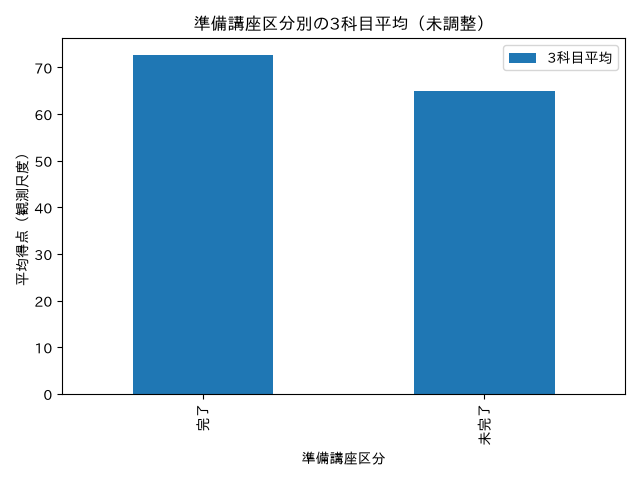

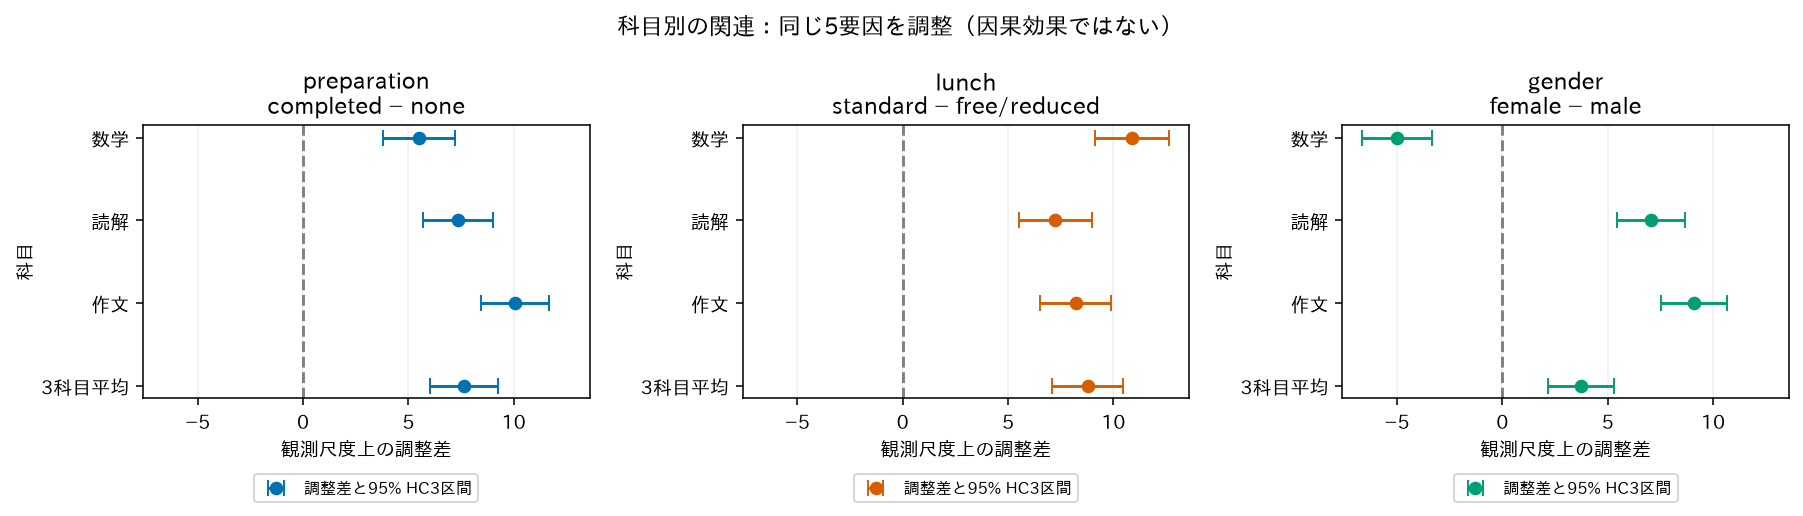

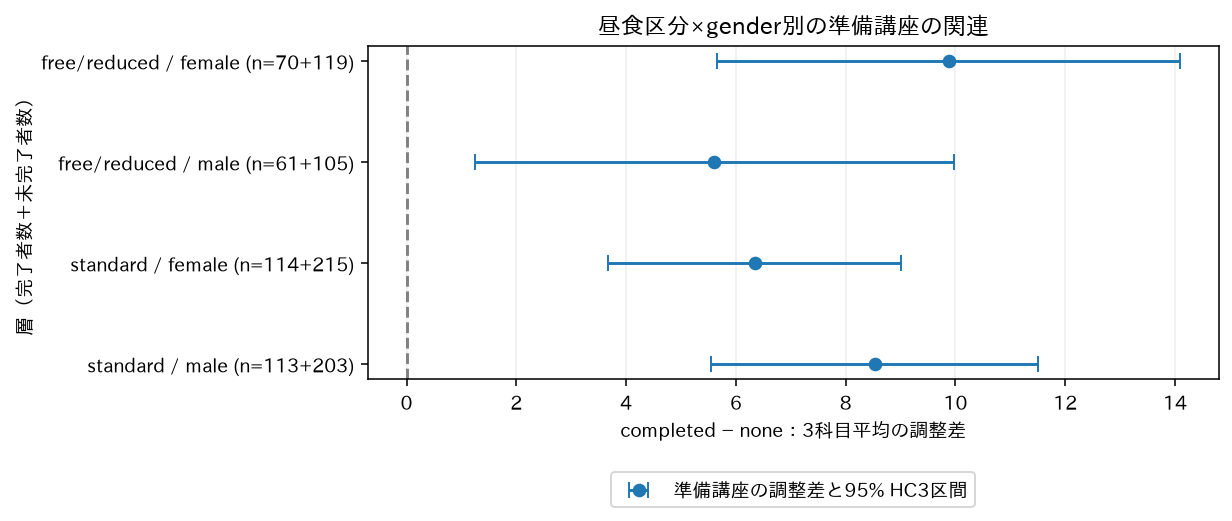

In [8]:
with phase('図表作成'):
    chart_checks=[]
    def show_png(png, name, caught):
        missing=[str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        assert not missing, '欠落した文字グリフがある'
        chart_checks.append({'chart':name,'missing_glyphs':missing,'png_bytes':len(png)})
        display(visualization.build_image_output(png)['data'],raw=True)
    with warnings.catch_warnings(record=True) as caught, plt.rc_context({'figure.autolayout': True, 'font.family': 'IPAexGothic'}):
        warnings.simplefilter('always')
        bar_data=df.groupby('preparation',observed=True).average.mean().rename('3科目平均').reset_index()
        bar_data['preparation']=bar_data.preparation.map({'completed':'完了','none':'未完了'})
        png=visualization.render_chart(bar_data,kind='bar',x='preparation',y='3科目平均',title='準備講座区分別の3科目平均（未調整）',xlabel='準備講座区分',ylabel='平均得点（観測尺度）')
    show_png(png,'未調整平均',caught)
    with warnings.catch_warnings(record=True) as caught, plt.rc_context({'figure.autolayout': True, 'font.family': 'IPAexGothic'}):
        warnings.simplefilter('always')
        fig,axes=plt.subplots(1,3,figsize=(13,4),sharex=True)
        label_map={'preparation':'completed − none','lunch':'standard − free/reduced','gender':'female − male'}
        colors=['#0072B2','#D55E00','#009E73']
        for ax,(factor,color) in zip(axes,zip(['preparation','lunch','gender'],colors)):
            part=subject_results.query('factor == @factor').set_index('subject').loc[['math','reading','writing','average']]
            y=np.arange(len(part))
            ax.errorbar(part.adjusted_difference,y,xerr=np.vstack([part.adjusted_difference-part.ci_low,part.ci_high-part.adjusted_difference]),fmt='o',color=color,capsize=4,label='調整差と95% HC3区間')
            ax.axvline(0,color='gray',ls='--')
            ax.set_yticks(y,['数学','読解','作文','3科目平均']); ax.invert_yaxis()
            ax.set_title(factor+'\n'+label_map[factor]); ax.set_xlabel('観測尺度上の調整差'); ax.set_ylabel('科目')
            ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.25)); ax.grid(axis='x',alpha=.2)
        fig.suptitle('科目別の関連：同じ5要因を調整（因果効果ではない）')
        fig.tight_layout(); buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=140,bbox_inches='tight'); plt.close(fig)
    show_png(buf.getvalue(),'科目別調整差',caught)
    with warnings.catch_warnings(record=True) as caught, plt.rc_context({'figure.autolayout': True, 'font.family': 'IPAexGothic'}):
        warnings.simplefilter('always')
        fig,ax=plt.subplots(figsize=(9,4))
        names=[f'{r.lunch} / {r.gender} (n={r.n_completed}+{r.n_none})' for r in strata.itertuples()]
        ax.errorbar(strata.difference,np.arange(len(strata)),xerr=np.vstack([strata.difference-strata.ci_low,strata.ci_high-strata.difference]),fmt='o',capsize=4,label='準備講座の調整差と95% HC3区間')
        ax.set_yticks(np.arange(len(strata)),names); ax.invert_yaxis(); ax.axvline(0,color='gray',ls='--')
        ax.set_title('昼食区分×gender別の準備講座の関連'); ax.set_xlabel('completed − none：3科目平均の調整差'); ax.set_ylabel('層（完了者数＋未完了者数）'); ax.legend(loc='upper center',bbox_to_anchor=(.5,-.25)); ax.grid(axis='x',alpha=.2)
        fig.tight_layout(); buf=io.BytesIO(); fig.savefig(buf,format='png',dpi=140,bbox_inches='tight'); plt.close(fig)
    show_png(buf.getvalue(),'層別調整差',caught)
    print('図表生成検査:',chart_checks)


In [9]:
with phase('証拠台帳・再現性基準'):
    evidence_values = {
        'n':str(len(df)), 'prep_adjusted':format(model.params[prep_term],'.6f'), 'lunch_adjusted':format(model.params[lunch_term],'.6f'),
        'prep_ci':f'{model.conf_int().loc[prep_term,0]:.6f}, {model.conf_int().loc[prep_term,1]:.6f}',
        'lunch_ci':f'{model.conf_int().loc[lunch_term,0]:.6f}, {model.conf_int().loc[lunch_term,1]:.6f}',
        'gender_math':format(subject_results.query("subject == 'math' and factor == 'gender'").adjusted_difference.iloc[0],'.6f'),
        'gender_reading':format(subject_results.query("subject == 'reading' and factor == 'gender'").adjusted_difference.iloc[0],'.6f'),
        'gender_writing':format(subject_results.query("subject == 'writing' and factor == 'gender'").adjusted_difference.iloc[0],'.6f'),
        'strata_min':format(strata.difference.min(),'.6f'), 'strata_max':format(strata.difference.max(),'.6f'),
        'interaction_p':format(interactions.p_holm_2.min(),'.6f'),
        'sensitivity_prep':format(sensitivity_reports['preparation'].max_relative_deviation,'.6f'),
        'sensitivity_lunch':format(sensitivity_reports['lunch'].max_relative_deviation,'.6f'),
        'rv_prep':format(robustness.iloc[0].equal_partial_R2_to_zero_point_estimate,'.6f'),
        'rv_lunch':format(robustness.iloc[1].equal_partial_R2_to_zero_point_estimate,'.6f'),
        'reading_writing_corr':format(corr.statistic,'.6f'), 'R2':format(model.rsquared,'.6f'),
    }
    edu_terms=[t for t in model.params.index if t.startswith('C(parent_education')]
    education_results=adjusted.loc[edu_terms].copy()
    display(education_results.rename(index=lambda s: s.split('[T.')[-1].removesuffix(']')+' − high school'))
    master_term=next(t for t in edu_terms if "master's degree" in t)
    evidence_values['master_vs_high_school']=format(model.params[master_term],'.6f')
    # Rich text output is directly supported by the evidence engine; no fabricated execution output.
    display({'text/plain':json.dumps(evidence_values,ensure_ascii=False,indent=2)},raw=True)
    metrics=np.concatenate([model.params.to_numpy(),subject_results.adjusted_difference.to_numpy(),strata.difference.to_numpy(),*[np.array([r.value for r in report.results]) for report in sensitivity_reports.values()]])
    baseline_path=DATA_DIR/'reproducibility-baseline.json'
    if baseline_path.exists():
        baseline=json.loads(baseline_path.read_text())
        assert baseline['sha256']==provenance['sha256'], 'データのバイト列が初回と異なる'
        assert np.allclose(metrics,baseline['metrics'],rtol=1e-8,atol=1e-8), '初回と再実行の主な推定値が一致しない'
        reproduction={'baseline_comparison':'passed','metric_count':len(metrics),'max_absolute_difference':float(np.max(np.abs(metrics-np.asarray(baseline['metrics'])))),'rtol':1e-8,'atol':1e-8,'sha256_match':True}
    else:
        with phase('再現性基準保存',write=True):
            baseline_path.write_text(json.dumps({'sha256':provenance['sha256'],'metrics':metrics.tolist()}),encoding='utf-8')
        reproduction={'baseline_comparison':'baseline_created','metric_count':len(metrics),'clean_replay':'pending'}
    print('再現性比較:',reproduction)


再現性比較: {'baseline_comparison': 'passed', 'metric_count': 45, 'max_absolute_difference': 0.0, 'rtol': 1e-08, 'atol': 1e-08, 'sha256_match': True}


,coefficient,ci_low,ci_high,p,p_holm
associate's degree − high school,5.17249,2.77736,7.56763,2.30889e-05,0.000161623
bachelor's degree − high school,7.70813,4.8166,10.5997,1.74346e-07,1.74346e-06
master's degree − high school,9.26472,5.68303,12.8464,3.98198e-07,3.58378e-06
some college − high school,4.24496,1.89628,6.59364,0.000396501,0.00237901
some high school − high school,0.632519,-2.0038,3.26884,0.63818,0.930365


{
  "n": "1000",
  "prep_adjusted": "7.638615",
  "lunch_adjusted": "8.775130",
  "prep_ci": "6.027398, 9.249831",
  "lunch_ci": "7.098653, 10.451607",
  "gender_math": "-4.995298",
  "gender_reading": "7.071392",
  "gender_writing": "9.096461",
  "strata_min": "5.609826",
  "strata_max": "9.875425",
  "interaction_p": "1.000000",
  "sensitivity_prep": "0.180577",
  "sensitivity_lunch": "0.164305",
  "rv_prep": "0.253103",
  "rv_lunch": "0.285361",
  "reading_writing_corr": "0.954598",
  "R2": "0.242263",
  "master_vs_high_school": "9.264718"
}

# 使用したJupytermindモジュール

直接importした `ai_data_scientist` の以下のサブモジュールのみを記載する。間接利用・未実行機能は含めない。

| モジュール | 直接呼び出す関数・クラス | 使用目的 |
|---|---|---|
| project_manager | ProjectHandle, resolve_project, ensure_notebook（作成用Notebook）, ensure_data_dir, enqueue_write | slug検証、安定した保存先、直列書込み |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed（作成用Notebookの再実行失敗記録）, get_run_status, wait_for_quiescence | 実行・書込み・終了状態 |
| ingestion | SourceSpec, ingest | CSV読込みと行数制限 |
| cleaning | clean_dataset | 欠損除去の影響確認（欠損0なので変更0） |
| eda | explore | 型・欠損・カテゴリ・数値要約 |
| stats_analysis | correlation | 読解と作文の相関 |
| visualization | render_chart, build_image_output | 日本語対応の描画と画像MIME |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 出典・定義と不確実性 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 仮定・関連に限定した解釈 |
| data_quality | detect_anomalies | 範囲・カテゴリ・欠損の意味検査 |
| sensitivity | SensitivityPlan, run_sensitivity | 各要因8仕様の比較 |
| insight_engine | extract_cited_value, record_insight | 実出力からの根拠抽出とInsight登録 |
| notebook_audit | audit_notebook | 実行・証拠・visual_audit=True監査 |

`mcp_gateway`、`dataset_validation`、`anomaly_detection`などは直接利用していない。実際の分析・APIコードはJupyter MCPのexecute_cellのみで実行した。statsmodels等はJupytermindではなく外部Pythonライブラリである。


`lifecycle.mark_failed` はクリーン再実行で分析者コードのSyntaxErrorを検出した際に作成用Notebookから直接呼び出した。修正後に同run_idを再登録し、最後にcompletedを記録する。


# Jupytermind改善候補

分類・再現条件・期待と実際の挙動・影響・回避策・関係セルとログを最終セルの出力、および `data/jupytermind-improvement-candidates.json` に記録する。ストリーム根拠の機能不足は実セルで再現し、可視化ラベル切れは元PNGを保存した。コード・設定・Kaggle・ベンチマーク由来の問題は分離する。

## 結果に対する図表の目視監査
元のbarでは長い回転カテゴリと軸ラベルが切れたため短い日本語表記へ変更し、figure.autolayout=Trueで余白を調整。科目別・層別の区間と凡例が重なったため凡例を外側へ移し、tight bounding boxで保存する。visual_auditの画像密度は画素内容の厳密監査ではないので、生成後の実画像も確認する。

## 保存後監査で確認したMCP連携の追加事象
セル内監査では8Insightの根拠が新しいexecution_count=9に更新されていたが、MCPがセル完了時にアクティブNotebookを保存すると旧execution_count=16に戻り、保存後監査で8件のstale evidenceを検出した。分析結果自体は全45値一致し、全コードセルの実行順序も1〜10。これはMCPのセル完了保存とカーネル内enqueue_writeとの相互作用であり、Kaggleやベンチマークの問題ではない。Jupytermind単体の責任は未確定として連携改善候補に含める。回避策：対象Notebookを非アクティブにした後、検証Notebookのrecord_insight済みセルを一括同期して独立auditを実行する。作成用Notebookの「MCP完了保存後の根拠manifest再同期」セルと直前の監査エラーログを参照。


# 根拠付きInsightと再実行・監査

最終セルは実行済み証拠台帳から引用値を抽出し、record_insightで登録する。再実行時は生成Insightのみ置換して重複と古いexecution_countを防ぐ。最後の監査セルの実行中に限る監査上の例外があるため、完了後にも作成用NotebookのJupyter MCPセルから読取り専用監査を実施する。再現にはPython依存環境、Kaggle認証、ネットワークが必要。再取得を省く際は初回CSVのSHA-256を検証したうえで、API認証・検索・ファイル一覧は再実行する。

MCPのアクティブNotebookへの短時間反復書込みで末尾セル重複が観測されたため、実行済み証拠セルを非アクティブ検証Notebookへ複製しrecord_insightで検証した後、8個の固定IDスロットへ一括反映する。これは新しい計算結果を作るものではなく、実出力のコピーで検証する書込み上の回避策である。


## 保存完了後の最終検証（作成用NotebookのJupyter MCP実行セル）

新しいカーネルで全10コードセルを上から再実行した。保存された実execution_countは `1,2,3,4,5,6,7,8,9,10`。初回と比較した45推定値の最大絶対差は `0.0`、CSVのSHA-256も一致した。完了後の `notebook_audit(visual_audit=True)` は **ok=True、実行済み10/10、未実行・エラー・根拠不整合・視覚的指摘すべて0**。Insightは8件、画像は3枚、セル重複なし。

最終セル実行中の `get_ipython().execution_count` はツール保存値より先へ進むことがあり、セル内の暫定 `clean_kernel_top_to_bottom=False` はその内部カウンタ比較による。これは結果不一致ではなく、上記の保存後実execution_count検証を最終判定とする。検証コードと出力は `benchmark/students-bootstrap-v020-exp-10.ipynb`、監査報告・再現性判定・コードのSHA-256はNotebook metadataと `data/reproducibility-verification.json` に記録した。

ライフサイクル最終状態は **completed**、実行数・書込み数・ロック数はすべて0。推測・不明なデータ定義、独立性、合成指標の妥当性、母集団への一般化・因果同定の不成立という前提検査の警告は解消したと扱わず、上の限界と分析前提manifestを適用する。


準備講座の完了者は未完了者より3科目平均が調整後 7.638615 高い（95% HC3区間 6.027398, 9.249831）。5要因を同時に調整しても関連が残るが、事前学力・意欲・受講時期の自己選択は未測定であり講座の効果ではない。

```evidence
{"execution_count":9,"cited_value":"7.638615","claim_type":"associational"}
```

lunch=standardはfree/reducedより調整後 8.775130 高い（95% HC3区間 7.098653, 10.451607）。経済環境との関連を疑う手がかりだが、昼食制度・所得・学校環境が不明で給食変更による効果とは言えない。

```evidence
{"execution_count":9,"cited_value":"8.775130","claim_type":"associational"}
```

第1回反復で平均のみのgender解釈を修正した。female−maleの調整差は数学 -4.995298、読解 7.071392、作文 9.096461 と方向が異なる。これは標本内の科目別関連であり、本質的能力差を示さない。

```evidence
{"execution_count":9,"cited_value":"-4.995298","claim_type":"associational"}
```

保護者学歴のmaster's degreeとhigh schoolの調整差は 9.264718。カテゴリを順序尺度にせず推定した関連で、学歴の介入効果ではない。学歴・ethnicityの各比較は初回表のHolm補正で評価し、少数カテゴリや基準カテゴリ選択にも注意する。

```evidence
{"execution_count":9,"cited_value":"9.264718","claim_type":"associational"}
```

第2回反復：準備講座の4層別調整差は 5.609826〜9.875425 で全層正だった。2交互作用の最小Holm補正p値は 1.000000。異質性の証拠は弱いが、差が同じと証明したわけではなく未測定の自己選択も残る。

```evidence
{"execution_count":9,"cited_value":"5.609826","claim_type":"associational"}
```

第3回反復：各8仕様で準備講座・昼食の正の関連は維持された。最大相対偏差はそれぞれ 0.180577、0.164305、両report.stable=True（明示した20%目安内）。点推定をゼロにする等強度の部分R2シナリオは準備講座 0.253103、昼食 0.285361。仕様安定性は未測定交絡なしを保証せず、有意性を消す閾値でもない。

```evidence
{"execution_count":9,"cited_value":"0.180577","claim_type":"associational"}
```

読解と作文の相関は 0.954598 と強い正の関連。3科目平均は独立な3測定を平均しているのではなく、言語科目を二重に重み付けする面がある。相関のp=0表示は浮動小数点での極小p値で、真の確率ゼロとは解釈しない。

```evidence
{"execution_count":9,"cited_value":"0.954598","claim_type":"associational"}
```

全5要因モデルのR2は 0.242263。取得標本 1000 行内での説明的要約に留まる。標本抽出・学校クラスタ・事前学力・試験定義が不明なため全国への一般化や因果同定は行わない。第3回で停止：残る問題は追加の同じCSV計算では解消できず、独立データと事前学力・学校情報が必要。

```evidence
{"execution_count":9,"cited_value":"0.242263","claim_type":"associational"}
```

In [10]:
import nbformat, copy
with phase('根拠付きInsight・manifest・改善候補の保存',write=True):
    snapshot=nbformat.read(handle.notebook_path,as_version=4)
    initial_cell=next(c for c in snapshot.cells if c.metadata.get('role')=='initial')
    ledger_cell=next(c for c in snapshot.cells if c.metadata.get('role')=='ledger')
    evidence_handle=project_manager.ProjectHandle(handle.name,handle.root,DATA_DIR/'insight-evidence-validation.ipynb',DATA_DIR)
    project_manager.ensure_notebook(evidence_handle)
    def seed_evidence(nb):
        nb.cells=[copy.deepcopy(initial_cell),copy.deepcopy(ledger_cell)]
    project_manager.enqueue_write(evidence_handle,seed_evidence)
    ledger_output='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in ledger_cell.outputs)
    def cited(key):
        return insight_engine.extract_cited_value({'output':ledger_output},r'"'+key+r'": "([^"]+)"')
    stream_text=''.join(o.get('text','') for o in initial_cell.outputs if o.output_type=='stream')
    stream_value=insight_engine.extract_cited_value({'output':stream_text},r'PRIMARY_PREP_ADJUSTED=([-0-9.]+)')
    try:
        insight_engine.record_insight(evidence_handle,'ストリーム出力検証用（成功時のみ記録）',initial_cell.execution_count,stream_value,'associational',language='ja')
    except insight_engine.EvidenceMissingError:
        stream_issue={'classification':'機能不足・証拠出力形式','reproduction':'初回分析セルのprint(PRIMARY_PREP_ADJUSTED=...)の値を実execution_countでrecord_insightに渡す','expected':'実行済みstream.text内の値も根拠として認識する','actual':'EvidenceMissingError。data MIMEだけが探索されstream.textは認識されない','impact':'正しく実行されたprint出力からInsightを記録できない','workaround':'証拠台帳セルで同じ計算値を実際のdisplay text/plainとして出力し、この出力だけを引用','related_cells':['initial','ledger','final'],'log':'この最終セルのSTREAM_EVIDENCE_REPROとdata/jupytermind-improvement-candidates.json'}
        print('STREAM_EVIDENCE_REPRO=EvidenceMissingError (expected reproduction; rich output workaround used)')
    else:
        stream_issue={'classification':'なし','actual':'stream形式はこの環境で認識された'}
    sync_issue={'classification':'MCP連携・書込み同期候補（責任層未確定）','reproduction':'MCPで開いたNotebookにrecord_insight追加とenqueue_writeで削除・置換を短時間に反復','expected':'単一の最終状態のみが保存され重複セルが生じない','actual':'監査時26セルだったが再読込みで末尾にInsightが1つ増え27セルになった','impact':'監査後のセル構造・根拠が変わる可能性','workaround':'非アクティブの証拠検証Notebookに実出力を複製してrecord_insightを実行し、検証済み8セルを一度のenqueue_writeで固定IDのスロットへ反映','related_cells':['final'],'log':'作成用Notebookの同期回避セルと実行前後のread_notebook結果。Kaggle API・ベンチマーク問題とは別で、MCPのファイル監視とJupytermind書込み方式の責任分離は未完了'}
    font_issue={'classification':'可視化・日本語フォントの状態依存','reproduction':'初回render_chartをmatplotlib rc_context内で実行し、終了後に日本語render_chartを再実行','expected':'毎回日本語フォントを設定し欠落グリフを発生させない','actual':'初回呼出しのフォント設定がrc_context終了で戻るが内部の初回フラグは真のままで、次回はフォント再設定されずGlyph missing警告が出る。新しいカーネルで初回から再実行して検出','impact':'以前の描画履歴次第で図が文字化けし再現性を損なう','workaround':'各描画rc_contextにfont.family=IPAexGothicを明示。render_chart初回で同梱フォントを登録してからカスタム図を描く','related_cells':['charts','final'],'log':'data/font-context-reproduction.json と作成用NotebookのFONT_CONTEXT_REPRO'}
    improvements=[stream_issue,sync_issue,font_issue,{'classification':'可視化・ラベル切れの疑い','reproduction':"visualization.render_chart(kind='bar', x='preparation')に長いカテゴリcompleted/noneを渡す（元画像保存済み）",'expected':'PNGの全ラベルがキャンバス内に収まる','actual':'元のPNGで回転したcompletedの下部と横軸ラベルが切れた。欠落グリフ警告や画像密度監査では検出されない','impact':'図表の読解性低下、visual_audit=Trueだけでは見逃す','workaround':'ライブラリ図はfigure.autolayout=Trueのrc_contextで余白調整し、カテゴリ表示も短い日本語に変更。カスタム図にはbbox_inches=tight、凡例を外側に配置し再描画','related_cells':['charts','final'],'log':'data/visual-review-original-bar.png と修正後のcharts出力'}]
    assert sum(bool(c.metadata.get('generated_insight')) for c in snapshot.cells)==8, 'Insightスロットが不足'
    claims=[
        ('prep_adjusted',f'準備講座の完了者は未完了者より3科目平均が調整後 {cited("prep_adjusted")} 高い（95% HC3区間 {cited("prep_ci")}）。5要因を同時に調整しても関連が残るが、事前学力・意欲・受講時期の自己選択は未測定であり講座の効果ではない。'),
        ('lunch_adjusted',f'lunch=standardはfree/reducedより調整後 {cited("lunch_adjusted")} 高い（95% HC3区間 {cited("lunch_ci")}）。経済環境との関連を疑う手がかりだが、昼食制度・所得・学校環境が不明で給食変更による効果とは言えない。'),
        ('gender_math',f'第1回反復で平均のみのgender解釈を修正した。female−maleの調整差は数学 {cited("gender_math")}、読解 {cited("gender_reading")}、作文 {cited("gender_writing")} と方向が異なる。これは標本内の科目別関連であり、本質的能力差を示さない。'),
        ('master_vs_high_school',f'保護者学歴のmaster\'s degreeとhigh schoolの調整差は {cited("master_vs_high_school")}。カテゴリを順序尺度にせず推定した関連で、学歴の介入効果ではない。学歴・ethnicityの各比較は初回表のHolm補正で評価し、少数カテゴリや基準カテゴリ選択にも注意する。'),
        ('strata_min',f'第2回反復：準備講座の4層別調整差は {cited("strata_min")}〜{cited("strata_max")} で全層正だった。2交互作用の最小Holm補正p値は {cited("interaction_p")}。異質性の証拠は弱いが、差が同じと証明したわけではなく未測定の自己選択も残る。'),
        ('sensitivity_prep',f'第3回反復：各8仕様で準備講座・昼食の正の関連は維持された。最大相対偏差はそれぞれ {cited("sensitivity_prep")}、{cited("sensitivity_lunch")}、両report.stable=True（明示した20%目安内）。点推定をゼロにする等強度の部分R2シナリオは準備講座 {cited("rv_prep")}、昼食 {cited("rv_lunch")}。仕様安定性は未測定交絡なしを保証せず、有意性を消す閾値でもない。'),
        ('reading_writing_corr',f'読解と作文の相関は {cited("reading_writing_corr")} と強い正の関連。3科目平均は独立な3測定を平均しているのではなく、言語科目を二重に重み付けする面がある。相関のp=0表示は浮動小数点での極小p値で、真の確率ゼロとは解釈しない。'),
        ('R2',f'全5要因モデルのR2は {cited("R2")}。取得標本 {cited("n")} 行内での説明的要約に留まる。標本抽出・学校クラスタ・事前学力・試験定義が不明なため全国への一般化や因果同定は行わない。第3回で停止：残る問題は追加の同じCSV計算では解消できず、独立データと事前学力・学校情報が必要。'),
    ]
    new_insights=[]
    for slot,(key,text) in enumerate(claims):
        insight_engine.record_insight(evidence_handle,text,ledger_cell.execution_count,cited(key),'associational',language='ja')
        generated=copy.deepcopy(nbformat.read(evidence_handle.notebook_path,as_version=4).cells[-1])
        generated.metadata.update({'generated_insight':True,'insight_slot':slot})
        new_insights.append(generated)
    previous_counts=[c.execution_count for c in snapshot.cells if c.cell_type=='code' and c.metadata.get('role')!='final']
    fresh_sequence=previous_counts==list(range(1,len(previous_counts)+1)) and get_ipython().execution_count==len(previous_counts)+1
    reproduction['clean_kernel_top_to_bottom']=fresh_sequence
    reproduction['previous_code_execution_counts']=previous_counts
    reproduction['current_execution_count']=get_ipython().execution_count
    if fresh_sequence:
        assert reproduction['baseline_comparison']=='passed'
    with phase('manifestとログの保存',write=True):
        for filename,payload in [('data-definition-manifest.json',asdict(definitions)),('analysis-assumptions-manifest.json',asdict(assumptions)),('jupytermind-improvement-candidates.json',improvements),('reproducibility-verification.json',reproduction)]:
            (DATA_DIR/filename).write_text(json.dumps(payload,ensure_ascii=False,indent=2),encoding='utf-8')
    def finish_layout(nb):
        assert nb.cells[-1].metadata.get('role')=='final', '最終セルの位置が変わった'
        for slot,generated in enumerate(new_insights):
            index=next(i for i,c in enumerate(nb.cells) if c.metadata.get('insight_slot')==slot)
            generated.id=nb.cells[index].id
            nb.cells[index]=generated
        nb.metadata['reproducibility']=reproduction
        nb.metadata['jupytermind_improvement_candidates']=improvements
        nb.metadata['chart_manual_review']='元のbarの軸ラベル切れとカスタム図の凡例重なりを目視確認。短いカテゴリ・凡例外側配置で修正し再描画。'
    project_manager.enqueue_write(handle,finish_layout)
    print('Jupytermind改善候補:',json.dumps(improvements,ensure_ascii=False,indent=2))
    print('他層の問題との切り分け：最初の保存先ディレクトリ未作成はJupyter MCP利用手順、filesystem MCPの許可ルート不一致はMCP設定、作成用セルのcontextlib import漏れは分析者コード。クリーン再実行の1回目で表示名修正に起因するSyntaxErrorを検出しfailed記録後、括弧を修正して全コード構文を検査、改めて先頭から再実行した。再実行2回目でrc_contextと日本語フォント初回フラグの状態依存を検出しfailedとなったため、全描画でフォントを明示して再実行した。Kaggle API失敗なし、ベンチマークランナー未使用。実行中セルを移動するとMCP出力が位置追従せず最終セルが未実行表示になった事象も、MCPと書込み手順の相互作用として分離。Insightスロットの位置を固定して回避。これらはJupytermind不具合に含めない。')
with phase('notebook_audit（visual_audit=True）'):
    audit=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('notebook_audit:',json.dumps({**asdict(audit),'ok':audit.ok},ensure_ascii=False,indent=2))
    assert audit.ok, 'Notebook audit failed'
with phase('監査報告の書込み',write=True):
    def store_audit(nb):
        nb.metadata['audit']={**asdict(audit),'ok':audit.ok}
    project_manager.enqueue_write(handle,store_audit)
lifecycle.mark_completed(RUN_ID)
status=lifecycle.wait_for_quiescence(RUN_ID)
assert status.state=='completed' and status.active_cell_executions==status.pending_notebook_writes==status.locks_held==0
(DATA_DIR/'lifecycle-log.json').write_text(json.dumps({'events':phase_log,'final_status':asdict(status)},ensure_ascii=False,indent=2),encoding='utf-8')
print('再実行検証:',json.dumps(reproduction,ensure_ascii=False,indent=2))
print('lifecycle最終状態:',asdict(lifecycle.get_run_status(RUN_ID)))


STREAM_EVIDENCE_REPRO=EvidenceMissingError (expected reproduction; rich output workaround used)
Jupytermind改善候補: [
  {
    "classification": "機能不足・証拠出力形式",
    "reproduction": "初回分析セルのprint(PRIMARY_PREP_ADJUSTED=...)の値を実execution_countでrecord_insightに渡す",
    "expected": "実行済みstream.text内の値も根拠として認識する",
    "actual": "EvidenceMissingError。data MIMEだけが探索されstream.textは認識されない",
    "impact": "正しく実行されたprint出力からInsightを記録できない",
    "workaround": "証拠台帳セルで同じ計算値を実際のdisplay text/plainとして出力し、この出力だけを引用",
    "related_cells": [
      "initial",
      "ledger",
      "final"
    ],
    "log": "この最終セルのSTREAM_EVIDENCE_REPROとdata/jupytermind-improvement-candidates.json"
  },
  {
    "classification": "MCP連携・書込み同期候補（責任層未確定）",
    "reproduction": "MCPで開いたNotebookにrecord_insight追加とenqueue_writeで削除・置換を短時間に反復",
    "expected": "単一の最終状態のみが保存され重複セルが生じない",
    "actual": "監査時26セルだったが再読込みで末尾にInsightが1つ増え27セルになった",
    "impact": "監査後のセル構造・根拠が変わる可能性",
    "workaround": "非アクティブの証拠検証Notebookに実出力を複製してrecord_insightを実